Librerías necesarias.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tkinter import *
from tkinter import ttk
from PIL import Image, ImageDraw, ImageFont, ImageTk
import mediapipe as mp


TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil.

In [19]:
img = cv2.imread('mandril.jpg')
# Convert the original BGR image to grayscale
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# Detect contours using the Canny edge detector
# Parameters: input image, lower threshold, upper threshold
canny = cv2.Canny(gris, 100, 200)

# Count the number of white pixels (255) per row
# Sum pixel values across each row
row_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Normalize by dividing by the number of columns (shape[1]) and the max pixel value (255)
# The result is the number of white pixels per row 

rows = row_counts / (255 * canny.shape[1])

# Find the largest proportion of white pixels in any row
maxfil = np.max(rows)


# Get the indices of rows that have at least 90% of the maximum white pixels
count = np.where(rows >= maxfil*0.9)[0]

print(count)
print("Número de filas con más del 90% de píxeles blancos: ", len(count))


[  6  12  15  20  21  88 100]
Número de filas con más del 90% de píxeles blancos:  7


TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Las filas:  [  2   3   4   5   8  11  12  19  20  24  51  80  81  82  83  84  85  87
 100]  y las columnas:  [104 105 127 288]  tiene un valor por encima de 0.9*máximo
El valor máximo encontrado por filas es:  55080
El valor máximo encontrado por filas es:  55845


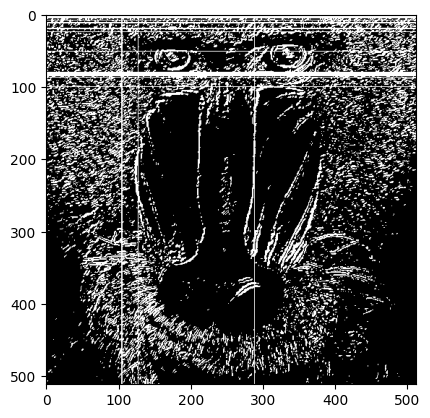

In [ ]:
# Conversion to gray image
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussian to smooth the original image, removing high frequencies
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

# Applying sobel in both axes
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Merging both results
sobel = cv2.add(sobelx, sobely)

# openCV byte conversion
sobel8 = cv2.convertScaleAbs(sobel)

# Aplying thresholding
THRESHOLD_VALUE = 100
_, imagenUmbralizada = cv2.threshold(sobel8, THRESHOLD_VALUE, 255, cv2.THRESH_BINARY)

# Getting dimensions of image
HEIGHT, WIDTH  = imagenUmbralizada.shape

# Counting by row and columns
row_count = cv2.reduce(imagenUmbralizada, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
col_count = cv2.reduce(imagenUmbralizada, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Getting the maximum value by row and columns 
MAX_VALUES_ROWS = row_count.max()
MAX_VALUES_COLUMNS = col_count.max()

# Normalization 
rows = row_count / (255*sobel8.shape[1])
cols = col_count / (255*sobel8.shape[0])

# Getting MAXFIL for Column and Rows
MAXFIL_ROW = rows.max()
MAXFIL_COL = cols.max()

# Getting indexes of the columns and rows that have a higher white value than 0.9 * maximum
X_INDEXES = np.where(rows > (0.9*MAXFIL_ROW))[0]
Y_INDEXES = np.where(cols > (0.9*MAXFIL_COL))[1]

# Displaying the indexes
print("Las filas: ", X_INDEXES, " y las columnas: ", Y_INDEXES, " tiene un valor por encima de 0.9*máximo")
print("El valor máximo encontrado por filas es: ", MAX_VALUES_ROWS)
print("El valor máximo encontrado por columnas es: ", MAX_VALUES_COLUMNS)
# Drawing white lines over the desired columns and rows
for x in X_INDEXES:
    cv2.line(imagenUmbralizada, (0, x), (HEIGHT, x), (255, 255, 255))
for y in Y_INDEXES:
    cv2.line(imagenUmbralizada, (y, 0), (y, HEIGHT), (255, 255, 255))

# Finally, displaying the image
plt.imshow(cv2.cvtColor(imagenUmbralizada, cv2.COLOR_GRAY2BGR))
plt.show()

Podemos ver que para Sobel obtenemos muchas más filas que tienen un valor de blanco superior a 0.9*maxfil, mientras que con Canny obtenemos muchas más columna que cumplen ese criterio. Además comparando las imagenes, Canny detecta mejor el contorno (se ve de mejor forma la cara del mono) que Sobel, pero Sobel detecta mejor los detalles (nótese como marca mejor los bordes del pelaje que Canny)

TAREA: Proponer un demostrador que capture las imágenes de la cámara, y les permita exhibir lo aprendido en estas dos prácticas ante quienes no cursen la asignatura :). Es por ello que además de poder mostrar la imagen original de la webcam, permita cambiar de modo, incluyendo al menos dos procesamientos diferentes como resultado de aplicar las funciones de OpenCV trabajadas hasta ahora.

In [ ]:
vid = cv2.VideoCapture(0)

def update_normal_image_view(color_image):
    new_image = ImageTk.PhotoImage(Image.fromarray(color_image))
    normal_mode_label.config(image=new_image)
    normal_mode_label.image = new_image
    return

def update_black_and_white_view(gray_image):
    gray_image = ImageTk.PhotoImage(Image.fromarray(gray_image))
    black_and_white_mode_label.config(image=gray_image)
    black_and_white_mode_label.image = gray_image
    return

def update_darkest_and_brightest_view(gray_image, color_image):
    minVal, maxVal, minLoc, maxLoc = cv2.minMaxLoc(gray_image)
    drawed_image = color_image.copy()
    cv2.circle(drawed_image, maxLoc, 7, (0, 0, 255), 3)
    cv2.circle(drawed_image, minLoc, 7, (255, 0, 0), 3)
    new_image = ImageTk.PhotoImage(Image.fromarray(drawed_image))
    darkest_and_brightest_mode_label.config(image=new_image)
    darkest_and_brightest_mode_label.image = new_image
    return

def update_tresholding_view(gray_image):
    valorUmbral = 75 
    _, imagenUmbralizada = cv2.threshold(gray_image, valorUmbral, 255, cv2.THRESH_BINARY)
    tresholded_image = ImageTk.PhotoImage(Image.fromarray(imagenUmbralizada))
    thresholding_mode_label.config(image=tresholded_image)
    thresholding_mode_label.image = tresholded_image
    return

def update_border_view(gray_image):
    canny_image = cv2.Canny(gray_image, 50, 175)
    border_image = ImageTk.PhotoImage(Image.fromarray(canny_image))
    border_mode_label.config(image=border_image)
    border_mode_label.image = border_image
    return

def update_image_difference_view(pframe, color_image):
    diff = cv2.absdiff(pframe, color_image)
    diff = ImageTk.PhotoImage(Image.fromarray(diff))
    frame_substraction_mode_label.config(image=diff)
    frame_substraction_mode_label.image = diff
    return

def update_views(recursive = True):
    """
    This functions is called periodically to update 
    the image displayed on the labels of the frame
    """
    global pframe
    ret, webcam_frame = vid.read()
    if (ret):
        # Aplying filters to the images and inserting on the labels
        color_image = cv2.cvtColor(webcam_frame, cv2.COLOR_BGR2RGB)
        gray_image = cv2.cvtColor(webcam_frame, cv2.COLOR_BGR2GRAY)
        selected_index = frame.index("current")  # get the index of the currently selected tab
        selected_tab_text = frame.tab(selected_index, "text")  # Get the text label of the currently selected tab

        if selected_tab_text == "Normal mode":
            update_normal_image_view(color_image)
        elif selected_tab_text == "Black and white":
            update_black_and_white_view(gray_image)
        elif selected_tab_text == "Darkest and brightest pixel":
            update_darkest_and_brightest_view(gray_image, color_image)
        elif selected_tab_text == "Thresholding":
            update_tresholding_view(gray_image)
        elif selected_tab_text == "Border detector":
            update_border_view(gray_image)
        elif selected_tab_text == "Frame substraction" and pframe is not None:
            update_image_difference_view(pframe, color_image)
        
        pframe = color_image.copy()
    if recursive:
        window.after(30, update_views)
    return


# Preparing window, frames, and labels.
# Window creation and initialization
window = Tk()
window.title("Tarea 3 - Demo")
window.minsize(int(vid.get(cv2.CAP_PROP_FRAME_WIDTH)), int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT)))
# Adding a notebook (similar to a tabbedpane on java's swing)
frame = ttk.Notebook(window)
frame.pack()

# Creating labels for tabs
normal_mode_label = Label(frame)
black_and_white_mode_label = Label(frame)
darkest_and_brightest_mode_label = Label(frame)
thresholding_mode_label = Label(frame)
border_mode_label = Label(frame)
frame_substraction_mode_label = Label(frame)

# Adding label of tabs to the frame
frame.add(normal_mode_label, text="Normal mode")
frame.add(black_and_white_mode_label, text="Black and white")
frame.add(darkest_and_brightest_mode_label, text="Darkest and brightest pixel")
frame.add(thresholding_mode_label, text="Thresholding")
frame.add(border_mode_label, text="Border detector")
frame.add(frame_substraction_mode_label, text="Frame substraction")

frame.bind("<<NotebookTabChanged>>", lambda e: update_views(False))


# Starting window
pframe = None
window.after(10, update_views)
window.mainloop()
vid.release()
window.quit()
cv2.destroyAllWindows()

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:

# Number of cells
cell_size = 10
off = int(cell_size/2)
# Importing necessary classes to detect hands and drawing utilities
mp_hands = mp.solutions.hands.Hands(static_image_mode=False)
mp_drawing = mp.solutions.drawing_utils

# Getting videocamera image
vid = cv2.VideoCapture(0)
  
while(True):      
    ret, frame = vid.read()

    if ret:
        # Getting image as RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Processing the image hand solution from mediapipe
        results = mp_hands.process(frame)
        # When a hand is detected the image is processed
        if results.multi_hand_landmarks: 
            # Getting dimnesions
            h, w, c = frame.shape
            # Resizing according to the number of cells
            down_frame = cv2.resize(frame, (int(w/cell_size),int(h/cell_size)),cv2.INTER_NEAREST)
            # New dimensions after resizing
            h2, w2, c2 = down_frame.shape

            # Getting each channel
            r = down_frame[:,:,0]
            g = down_frame[:,:,1]
            b = down_frame[:,:,2]

            # Creating an empty black image with the proper size according the current dimensions of the image and the number of cells
            gris_up_frame = np.zeros((h2*cell_size,w2*cell_size,1), dtype = np.uint8)

            # Traversing the pixels of the image
            for y in range(0,h2):
                for x in range(0,w2):
                    # Getting radius from the RGB sum
                    rad = int ( (r[y,x] + g[y,x] + b[y,x])/(cell_size*3*2))
                    # Adding the circle
                    cv2.circle(gris_up_frame,(x*cell_size+off, y*cell_size + off), rad, (255,255,255), -1)
            # Updating frame with the image processed
            frame = gris_up_frame
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

        # Display the image cell_size
        cv2.imshow('Fotograma', frame)
  
   
    # Press Esc to stop
    if cv2.waitKey(20) == 27:
        break
  
# Releasing resources
vid.release()
# Destroying windows
cv2.destroyAllWindows()